<a href="https://colab.research.google.com/github/SamanaDahal1/AI-and-ML/blob/main/Week4(workshop4)AI_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical


def load_data(path):
    X, y = [], []

    if not os.path.exists(path):
        print(f"Error: Directory '{path}' does not exist. Returning empty dataset.")
        return np.array([]), np.array([])

    label_folders = os.listdir(path)
    if not label_folders:
        print(f"Warning: Directory '{path}' is empty or contains no subfolders. Returning empty dataset.")
        return np.array([]), np.array([])

    for label_folder_name in label_folders: # e.g., 'digit_0', 'digit_1'
        folder_path = os.path.join(path, label_folder_name)

        if not os.path.isdir(folder_path):
            continue

        try:
            # Assumes label folder names are like 'digit_0', 'digit_1', etc.
            label_int = int(label_folder_name.split('_')[1])
        except (IndexError, ValueError) as e:
            print(f"Warning: Skipping folder '{label_folder_name}' in '{path}' due to invalid label format: {e}")
            continue

        # Check if folder_path contains files before iterating
        if not os.listdir(folder_path):
            print(f"Warning: Folder '{folder_path}' is empty. Skipping.")
            continue

        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)

            try:
                img = Image.open(img_path).convert('L').resize((28,28))
                X.append(np.array(img))
                y.append(label_int)
            except Exception as e:
                # Log specific image processing errors, but don't stop execution for a single bad image
                print(f"Warning: Could not process image '{img_path}': {e}")
                continue

    # If no images were successfully loaded, return empty arrays
    if not X:
        print(f"Warning: No images loaded from '{path}'. Returning empty dataset.")
        return np.array([]), np.array([])

    return np.array(X), np.array(y)


X_train, y_train = load_data("/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train")
X_test, y_test = load_data("/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test")

# --- Post-loading checks and preprocessing ---

# Check if training data was loaded
if len(X_train) == 0:
    raise ValueError("No training data was loaded. Please check the training dataset path and contents.")

# Check if test data was loaded
if len(X_test) == 0:
    raise ValueError("No test data was loaded. Please check the test dataset path and contents.")

# normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# flatten
X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

# one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Data loading and preprocessing complete.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Data loading and preprocessing complete.
X_train shape: (6845, 784), y_train shape: (6845, 10)
X_test shape: (3000, 784), y_test shape: (3000, 10)


In [3]:
import os
print(os.listdir())

['.config', 'drive', 'sample_data']


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Hidden layers
model.add(Dense(64, activation='sigmoid', input_shape=(784,)))
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(256, activation='sigmoid'))

# Output layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/20
39/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1787 - loss: 2.1119
Epoch 1: val_accuracy improved from None to 0.00657, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.2703 - loss: 2.0041 - val_accuracy: 0.0066 - val_loss: 7.1646
Epoch 2/20
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7575 - loss: 1.5225
Epoch 2: val_accuracy did not improve from 0.00657
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7997 - loss: 1.2571 - val_accuracy: 0.0066 - val_loss: 7.3628
Epoch 3/20
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8727 - loss: 0.6108
Epoch 3: val_accuracy did not improve from 0.00657
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8917 - loss: 0.4978 - val_accuracy: 0.0066 - val_loss: 8.0431
Epoch 4/20
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9514 - loss: 0.2893
Epoch 4: val_accuracy did not improve from 0.00657
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9556 - loss: 0.2566 - val_accuracy: 0.0066 - val_loss: 8.5714


In [7]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4400 - loss: 2.8814
Test Loss: 2.8813822269439697
Test Accuracy: 0.4399999976158142


In [8]:
from tensorflow.keras.models import load_model

# Save model
model.save("devnagari_fcn_model.h5")

# Load model
loaded_model = load_model("devnagari_fcn_model.h5")

# Re-evaluate
loss, accuracy = loaded_model.evaluate(X_test, y_test)
print("Loaded Model Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4400 - loss: 2.8814
Loaded Model Accuracy: 0.4399999976158142


In [ ]:
import numpy as np

predictions = loaded_model.predict(X_test)

# Convert probabilities to labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual   :", true_labels[:10])

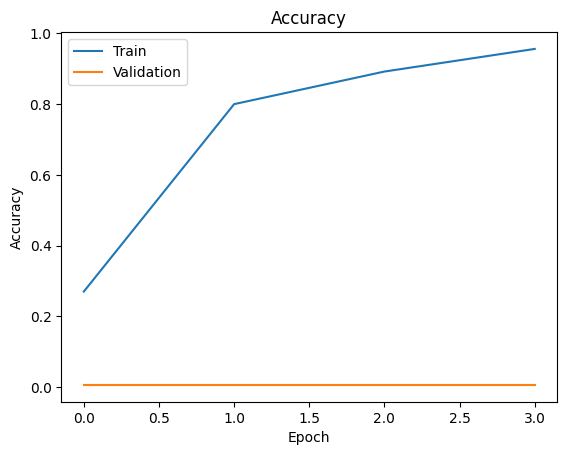

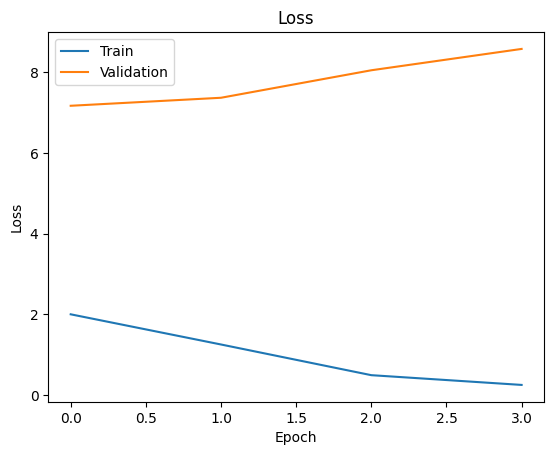

In [9]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()